# Experiment 8: Clustering Human Activity Recognition Data

UCI HAR smartphone sensor data, clustered with K-Means, DBSCAN and hierarchical (Ward) clustering and compared against the six known activities.

In [1]:
%matplotlib inline

In [2]:
import os
import time
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.cluster.hierarchy import linkage, dendrogram, fcluster, cophenet
from scipy.spatial.distance import pdist
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.feature_selection import f_classif
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import (silhouette_score, davies_bouldin_score, calinski_harabasz_score,
                              adjusted_rand_score, normalized_mutual_info_score)

RNG = 42
sns.set_style("whitegrid")

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['font.size'] = 15
plt.rcParams['legend.fontsize'] = 15
plt.rcParams['legend.title_fontsize'] = 15
plt.rcParams['axes.labelweight'] = 'bold'

## Load the data

In [3]:
if os.path.exists("UCI HAR Dataset"):
    base = "UCI HAR Dataset"
    X_raw = np.vstack([np.loadtxt(f"{base}/train/X_train.txt"),
                       np.loadtxt(f"{base}/test/X_test.txt")]).astype("float32")
    y_raw = np.concatenate([np.loadtxt(f"{base}/train/y_train.txt"),
                            np.loadtxt(f"{base}/test/y_test.txt")]).astype(int)
    subjects = np.concatenate([np.loadtxt(f"{base}/train/subject_train.txt"),
                               np.loadtxt(f"{base}/test/subject_test.txt")]).astype(int)
    feat = pd.read_csv(f"{base}/features.txt", sep=r"\s+", header=None)[1].tolist()
    activity_names = pd.read_csv(f"{base}/activity_labels.txt", sep=r"\s+", header=None)[1].tolist()
    np.savez_compressed("har_data.npz", X=X_raw, y=y_raw, subjects=subjects,
                        features=np.array(feat), activities=np.array(activity_names))
else:
    d = np.load("har_data.npz")
    X_raw, y_raw, subjects = d["X"], d["y"], d["subjects"]
    feat = d["features"].tolist()
    activity_names = d["activities"].tolist()

seen = {}
names = []
for f in feat:
    seen[f] = seen.get(f, 0) + 1
    names.append(f if seen[f] == 1 else f"{f}_{seen[f]}")

df = pd.DataFrame(X_raw, columns=names)
df["activity"] = [activity_names[i - 1] for i in y_raw]

print("Dataset shape:", df.shape)
print("Missing values:", df.isnull().sum().sum())
print("Volunteers:", len(np.unique(subjects)))
print(df["activity"].value_counts())

Dataset shape: (10299, 562)
Missing values: 0
Volunteers: 30
activity
LAYING                1944
STANDING              1906
SITTING               1777
WALKING               1722
WALKING_UPSTAIRS      1544
WALKING_DOWNSTAIRS    1406
Name: count, dtype: int64


## Preprocessing

In [4]:
le = LabelEncoder()
y_true = le.fit_transform(df["activity"])
X = StandardScaler().fit_transform(X_raw)
print(dict(zip(le.classes_, range(len(le.classes_)))))
print("Standardized shape:", X.shape, "| mean ~", round(float(X.mean()), 4), "| std ~", round(float(X.std()), 4))

{'LAYING': 0, 'SITTING': 1, 'STANDING': 2, 'WALKING': 3, 'WALKING_DOWNSTAIRS': 4, 'WALKING_UPSTAIRS': 5}
Standardized shape: (10299, 561) | mean ~ 0.0 | std ~ 1.0


## Helper functions

In [5]:
short = {"WALKING": "WALK", "WALKING_UPSTAIRS": "UP", "WALKING_DOWNSTAIRS": "DOWN",
         "SITTING": "SIT", "STANDING": "STAND", "LAYING": "LAY"}
order = activity_names
palette = dict(zip(order, sns.color_palette("tab10", 6)))

def clustering_metrics(X, labels, y_true):
    mask = labels != -1
    n_clusters = len(set(labels[mask]))
    out = dict(n_clusters=n_clusters, noise=1 - mask.mean())
    if n_clusters >= 2:
        out["silhouette"] = silhouette_score(X[mask], labels[mask])
        out["davies_bouldin"] = davies_bouldin_score(X[mask], labels[mask])
        out["calinski_harabasz"] = calinski_harabasz_score(X[mask], labels[mask])
    else:
        out["silhouette"] = out["davies_bouldin"] = out["calinski_harabasz"] = np.nan
    out["ari"] = adjusted_rand_score(y_true, labels)
    out["nmi"] = normalized_mutual_info_score(y_true, labels)
    return out

def build_eda_summary_figure(df, top_feats, pcs):
    fig, axes = plt.subplots(3, 4, figsize=(22, 15))
    axes = axes.ravel()

    counts = df["activity"].value_counts().reindex(order)
    axes[0].bar([short[a] for a in order], counts.values, color=[palette[a] for a in order])
    axes[0].set_title("Activity Distribution")
    axes[0].set_xlabel("Activity"); axes[0].set_ylabel("Windows")

    for i, feat_name in enumerate(top_feats[:6]):
        ax = axes[1 + i]
        for a in order:
            sns.kdeplot(df.loc[df["activity"] == a, feat_name], ax=ax, color=palette[a],
                        label=short[a], linewidth=1.5, warn_singular=False)
        ax.set_title(feat_name, fontsize=10)
        ax.set_xlabel("Value"); ax.set_ylabel("Density")
        if i == 0:
            ax.legend(fontsize=8)

    sns.heatmap(df[top_feats].corr(), annot=True, fmt=".2f", cmap="coolwarm", ax=axes[7],
                cbar=False, annot_kws={"size": 7},
                xticklabels=range(1, 11), yticklabels=range(1, 11))
    axes[7].set_title("Correlation of Top 10 Features", fontsize=13)

    for i, feat_name in enumerate(top_feats[:3]):
        ax = axes[8 + i]
        sns.boxplot(x="activity", y=feat_name, data=df, order=order, hue="activity", hue_order=order,
                    palette=palette, legend=False, showfliers=False, ax=ax)
        ax.set_xticklabels([short[a] for a in order], fontsize=9)
        ax.set_title(feat_name, fontsize=10)
        ax.set_xlabel("Activity"); ax.set_ylabel("Value")

    for a in order:
        m = (df["activity"] == a).values
        axes[11].scatter(pcs[m, 0], pcs[m, 1], s=4, alpha=0.5, color=palette[a], label=short[a])
    axes[11].set_xlabel("PC 1"); axes[11].set_ylabel("PC 2")
    axes[11].set_title("PCA Projection", fontsize=13)
    axes[11].legend(fontsize=8, markerscale=3)

    plt.tight_layout()
    return fig

def scatter_panel(ax, Z, labels, title):
    for lab in sorted(set(labels)):
        m = labels == lab
        if lab == -1:
            ax.scatter(Z[m, 0], Z[m, 1], s=3, color="lightgrey", alpha=0.6)
        else:
            ax.scatter(Z[m, 0], Z[m, 1], s=3, alpha=0.6)
    ax.set_title(title, fontsize=12)

## PCA and t-SNE for visualization

In [6]:
pca2 = PCA(n_components=2, random_state=RNG)
Z_pca = pca2.fit_transform(X)
print("2-D PCA explained variance:", round(pca2.explained_variance_ratio_.sum(), 4))

pca50 = PCA(n_components=50, random_state=RNG).fit(X)
X_pca50 = pca50.transform(X)
print("50-component PCA explained variance:", round(pca50.explained_variance_ratio_.sum(), 4))

t0 = time.perf_counter()
Z_tsne = TSNE(n_components=2, perplexity=30, init="pca", random_state=RNG, n_jobs=-1).fit_transform(X_pca50)
print("t-SNE time:", round(time.perf_counter() - t0, 1), "s")

2-D PCA explained variance: 0.5698


50-component PCA explained variance: 0.871


t-SNE time: 12.5 s


## EDA

Top features by ANOVA F: ['fBodyAccJerk-entropy()-X', 'tGravityAcc-mean()-X', 'tGravityAcc-min()-X', 'tGravityAcc-max()-X', 'tGravityAcc-energy()-X', 'fBodyAccJerk-entropy()-Y', 'fBodyBodyAccJerkMag-entropy()', 'tBodyAccJerkMag-entropy()', 'fBodyAcc-entropy()-X', 'tBodyAccJerk-entropy()-X']


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


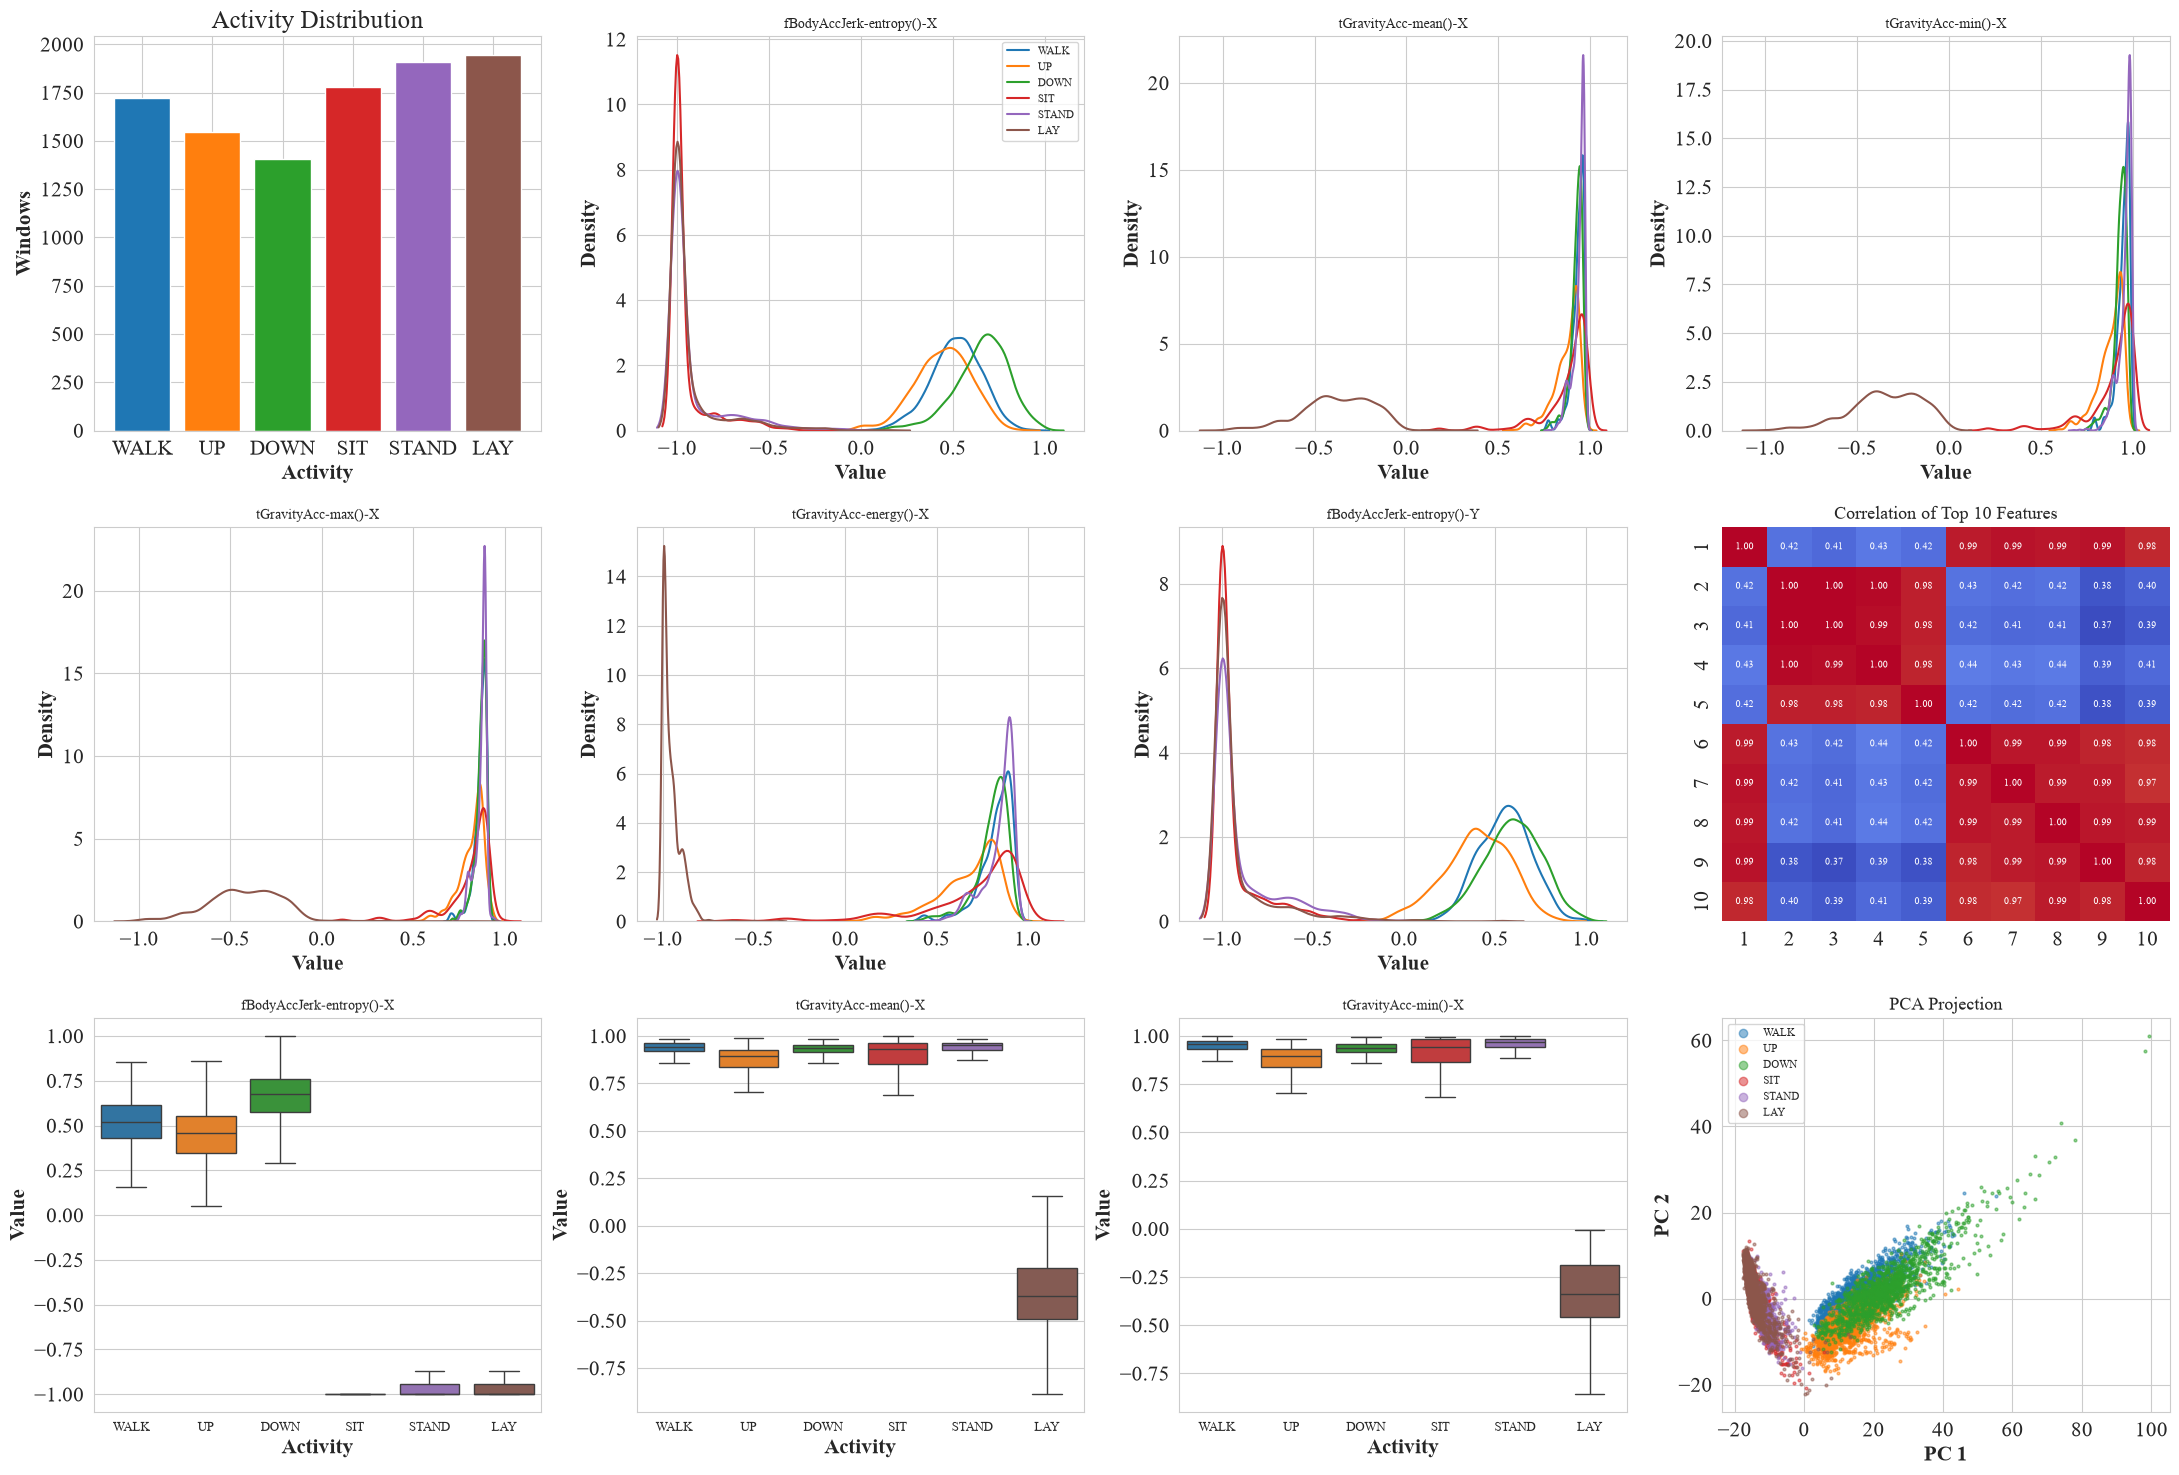

In [7]:
F, _ = f_classif(X, y_true)
top_feats = [names[i] for i in np.argsort(F)[::-1][:10]]
print("Top features by ANOVA F:", top_feats)

eda_fig = build_eda_summary_figure(df, top_feats, Z_pca)
eda_fig.savefig("figures/00_eda_summary.eps", format="eps", dpi=600)
eda_fig.savefig("figures/00_eda_summary.png", dpi=150)
plt.show()
plt.close(eda_fig)

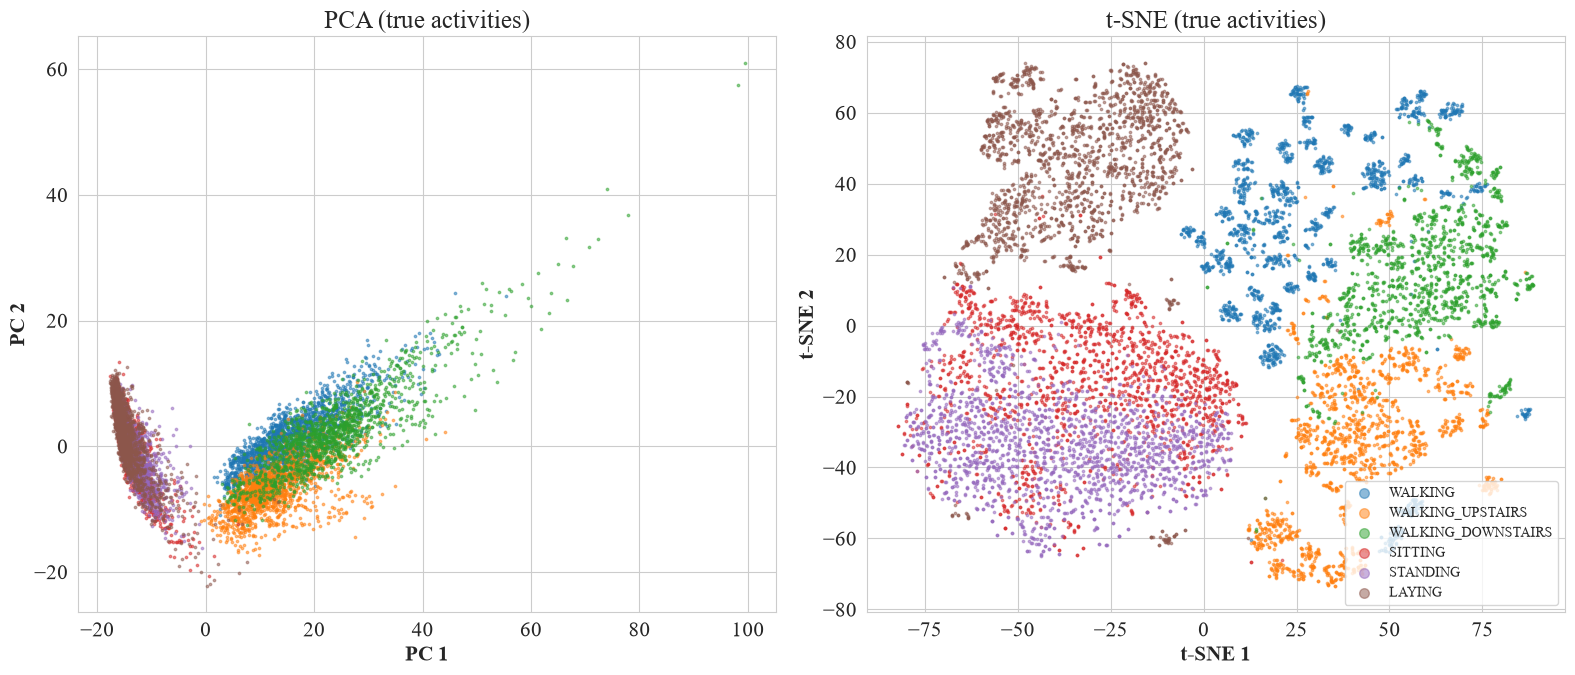

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for a in order:
    m = (df["activity"] == a).values
    axes[0].scatter(Z_pca[m, 0], Z_pca[m, 1], s=3, alpha=0.5, color=palette[a], label=a)
    axes[1].scatter(Z_tsne[m, 0], Z_tsne[m, 1], s=3, alpha=0.5, color=palette[a], label=a)
axes[0].set_title("PCA (true activities)"); axes[0].set_xlabel("PC 1"); axes[0].set_ylabel("PC 2")
axes[1].set_title("t-SNE (true activities)"); axes[1].set_xlabel("t-SNE 1"); axes[1].set_ylabel("t-SNE 2")
axes[1].legend(markerscale=4, fontsize=10)
plt.tight_layout()
plt.savefig("figures/01_ground_truth_pca_tsne.png", dpi=150)
plt.show()
plt.close()

## K-Means and the elbow method

In [9]:
ks = list(range(2, 9))
km_rows, km_models = [], {}
for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=RNG).fit(X)
    m = clustering_metrics(X, km.labels_, y_true)
    m.update(k=k, wcss=km.inertia_)
    km_rows.append(m)
    km_models[k] = km

km_df = pd.DataFrame(km_rows)[["k", "wcss", "silhouette", "davies_bouldin", "calinski_harabasz", "ari", "nmi"]]
print(km_df.to_string(index=False))
km_df.to_csv("kmeans_elbow_table.csv", index=False)

 k       wcss  silhouette  davies_bouldin  calinski_harabasz      ari      nmi
 2 3272857.25    0.393732        1.070744        7880.813888 0.329611 0.545464
 3 2921077.75    0.315484        1.786516        5034.475246 0.331698 0.518251
 4 2781602.00    0.150005        2.342158        3696.338707 0.299010 0.469354
 5 2654789.75    0.128631        2.410824        3027.324353 0.291165 0.460665
 6 2577180.50    0.109895        2.383567        2556.541943 0.419620 0.559326
 7 2519774.25    0.081599        2.675157        2217.855688 0.433248 0.554576
 8 2465378.75    0.074867        2.610563        1975.210682 0.426647 0.551610


## Choosing k

k by elbow (max distance from chord): 4
k by silhouette: 2


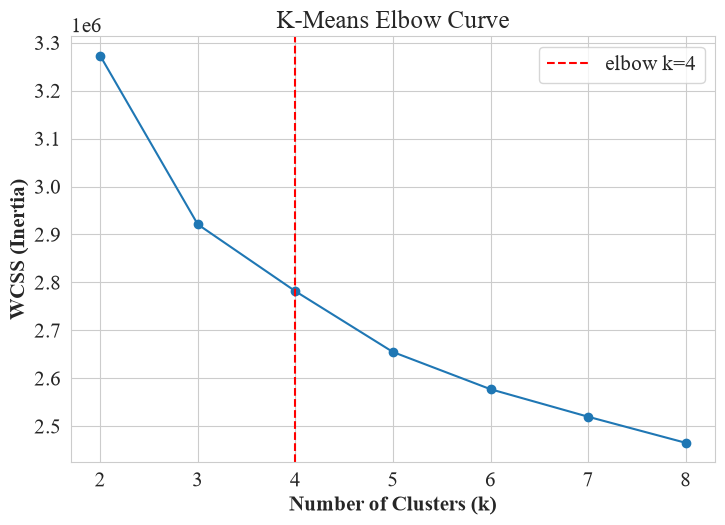

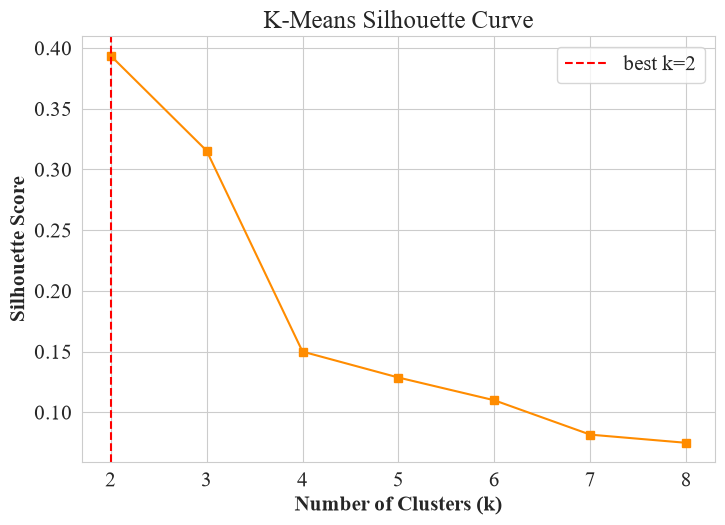

In [10]:
kv = km_df["k"].values.astype(float)
w = km_df["wcss"].values
xn = (kv - kv.min()) / (kv.max() - kv.min())
yn = (w - w.min()) / (w.max() - w.min())
k_elbow = int(kv[np.argmax(np.abs(yn - (1 - xn)))])
k_sil = int(km_df.loc[km_df["silhouette"].idxmax(), "k"])
best_k = k_sil
print("k by elbow (max distance from chord):", k_elbow)
print("k by silhouette:", k_sil)

plt.figure(figsize=(7.5, 5.5))
plt.plot(km_df["k"], km_df["wcss"], marker="o")
plt.axvline(k_elbow, color="red", linestyle="--", label=f"elbow k={k_elbow}")
plt.xlabel("Number of Clusters (k)"); plt.ylabel("WCSS (Inertia)")
plt.title("K-Means Elbow Curve")
plt.legend()
plt.tight_layout()
plt.savefig("figures/02_kmeans_elbow.png", dpi=150)
plt.show()
plt.close()

plt.figure(figsize=(7.5, 5.5))
plt.plot(km_df["k"], km_df["silhouette"], marker="s", color="darkorange")
plt.axvline(k_sil, color="red", linestyle="--", label=f"best k={k_sil}")
plt.xlabel("Number of Clusters (k)"); plt.ylabel("Silhouette Score")
plt.title("K-Means Silhouette Curve")
plt.legend()
plt.tight_layout()
plt.savefig("figures/03_kmeans_silhouette.png", dpi=150)
plt.show()
plt.close()

## DBSCAN

Full 561-D space, eps grid: [10.76 11.82 13.15 14.72 17.07 19.45]
  eps  min_samples  n_clusters  noise  silhouette  davies_bouldin  calinski_harabasz    ari    nmi
10.76            5          35 0.6074     -0.0101          1.6878            54.9340 0.1166 0.2644
10.76           10          12 0.6565      0.0797          1.4944            79.6303 0.0974 0.2332
10.76           20           3 0.6995      0.1242          1.3356           122.0373 0.0791 0.2040
11.82            5          32 0.4707      0.0612          1.9479           125.4320 0.1940 0.3635
11.82           10          20 0.5208      0.0752          2.0926           131.7093 0.1793 0.3355
11.82           20          10 0.5718      0.1383          1.7132           133.2967 0.1650 0.3060
13.15            5          30 0.3317      0.3006          1.6967           209.4632 0.2602 0.4073
13.15           10          14 0.3763      0.0634          2.0182           359.5414 0.2490 0.3977
13.15           20           4 0.4261      

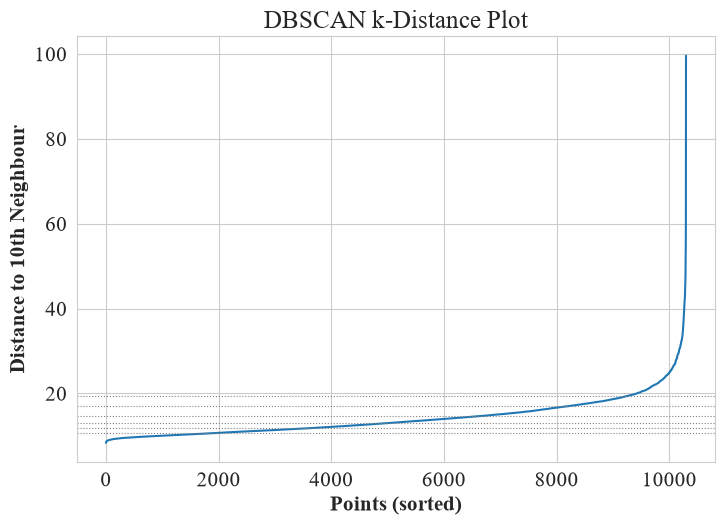

In [11]:
def dbscan_grid(Z, eps_values, minpts_values):
    rows, labels_by_config = [], {}
    for eps in eps_values:
        for mp in minpts_values:
            labels = DBSCAN(eps=float(eps), min_samples=mp, n_jobs=-1).fit_predict(Z)
            m = clustering_metrics(X, labels, y_true)
            m.update(eps=float(eps), min_samples=mp)
            rows.append(m)
            labels_by_config[(float(eps), mp)] = labels
    cols = ["eps", "min_samples", "n_clusters", "noise", "silhouette", "davies_bouldin",
            "calinski_harabasz", "ari", "nmi"]
    return pd.DataFrame(rows)[cols], labels_by_config

def pick_dbscan(grid):
    ok = grid[(grid["n_clusters"] >= 2) & (grid["n_clusters"] <= 12) & (grid["noise"] <= 0.30)]
    return ok.loc[ok["silhouette"].idxmax()] if len(ok) else grid.loc[grid["nmi"].idxmax()]

quantiles = [0.2, 0.35, 0.5, 0.65, 0.8, 0.9]
minpts_grid = [5, 10, 20]

kdist = np.sort(NearestNeighbors(n_neighbors=11).fit(X).kneighbors(X)[0][:, 10])
eps_full = np.round(np.quantile(kdist, quantiles), 2)
db_full, db_full_labels = dbscan_grid(X, eps_full, minpts_grid)
print("Full 561-D space, eps grid:", eps_full)
print(db_full.round(4).to_string(index=False))
best_db_full = pick_dbscan(db_full)
print("\nSelected:", dict(best_db_full.round(4)))

plt.figure(figsize=(7.5, 5.5))
plt.plot(kdist)
for e in eps_full:
    plt.axhline(e, color="grey", linestyle=":", linewidth=0.8)
plt.xlabel("Points (sorted)"); plt.ylabel("Distance to 10th Neighbour")
plt.title("DBSCAN k-Distance Plot")
plt.tight_layout()
plt.savefig("figures/04_dbscan_kdistance.png", dpi=150)
plt.show()
plt.close()

In [12]:
kdist_pca = np.sort(NearestNeighbors(n_neighbors=11).fit(X_pca50).kneighbors(X_pca50)[0][:, 10])
eps_pca = np.round(np.quantile(kdist_pca, quantiles), 2)
db_pca, db_pca_labels = dbscan_grid(X_pca50, eps_pca, minpts_grid)
print("50-component PCA space, eps grid:", eps_pca)
print(db_pca.round(4).to_string(index=False))
best_db_pca = pick_dbscan(db_pca)
print("\nSelected:", dict(best_db_pca.round(4)))

db_full.to_csv("dbscan_grid_full.csv", index=False)
db_pca.to_csv("dbscan_grid_pca50.csv", index=False)

50-component PCA space, eps grid: [ 7.13  8.18  9.55 10.98 12.76 14.68]
  eps  min_samples  n_clusters  noise  silhouette  davies_bouldin  calinski_harabasz    ari    nmi
 7.13            5          21 0.6343      0.0140          1.4454            38.8656 0.1154 0.2506
 7.13           10           6 0.6723      0.0999          1.2795            53.9009 0.0948 0.2217
 7.13           20           1 0.7134         NaN             NaN                NaN 0.0753 0.1940
 8.18            5          36 0.4920      0.1617          1.8896            80.6234 0.2016 0.3561
 8.18           10          12 0.5397      0.3663          1.7603           119.2384 0.1914 0.3333
 8.18           20           4 0.5798      0.1241          1.4405           114.6730 0.1756 0.3092
 9.55            5          40 0.3202      0.2770          1.7189           160.0673 0.2718 0.4221
 9.55           10          10 0.3803      0.3297          1.7628           470.4610 0.2602 0.4126
 9.55           20           4 0.4398

## Hierarchical clustering

  method  cophenetic  n_clusters  largest_cluster  silhouette  davies_bouldin  calinski_harabasz    ari    nmi
  single      0.8139           6           0.9994      0.5601          0.2733            28.8554 0.0001 0.0013
complete      0.7523           6           0.5463      0.3792          1.3004          1898.4100 0.3294 0.5421
 average      0.8557           6           0.9847      0.4431          1.1020           161.1037 0.0024 0.0220
    ward      0.6767           6           0.3115      0.1170          2.4820          2349.6677 0.4599 0.6015



sklearn Ward vs scipy Ward agreement (ARI): 1.0


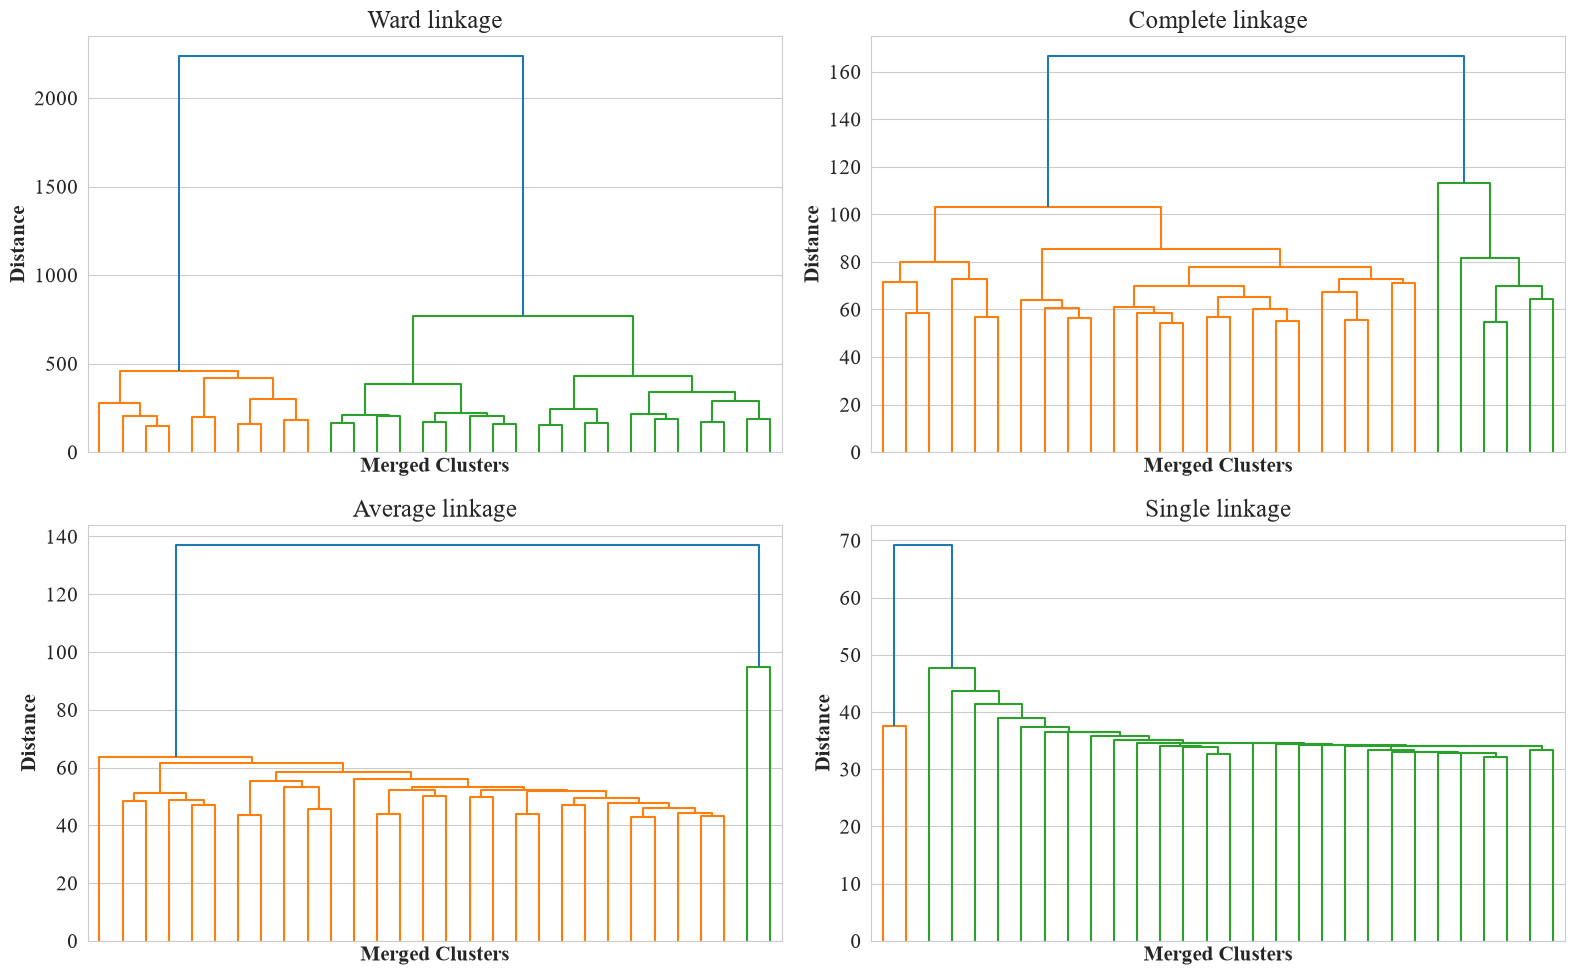

In [13]:
D = pdist(X)
link_rows, link_labels, link_Z = [], {}, {}
for method in ["single", "complete", "average", "ward"]:
    Zm = linkage(D, method=method)
    lab = fcluster(Zm, t=6, criterion="maxclust") - 1
    m = clustering_metrics(X, lab, y_true)
    m["method"] = method
    m["cophenetic"] = cophenet(Zm, D)[0]
    m["largest_cluster"] = np.bincount(lab).max() / len(lab)
    link_rows.append(m)
    link_labels[method] = lab
    link_Z[method] = Zm

link_df = pd.DataFrame(link_rows)[["method", "cophenetic", "n_clusters", "largest_cluster", "silhouette",
                                    "davies_bouldin", "calinski_harabasz", "ari", "nmi"]]
print(link_df.round(4).to_string(index=False))
link_df.to_csv("linkage_comparison.csv", index=False)

hac = AgglomerativeClustering(n_clusters=6, linkage="ward").fit(X)
print("\nsklearn Ward vs scipy Ward agreement (ARI):", round(adjusted_rand_score(hac.labels_, link_labels["ward"]), 4))

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
for ax, method in zip(axes.ravel(), ["ward", "complete", "average", "single"]):
    dendrogram(link_Z[method], truncate_mode="lastp", p=30, no_labels=True, ax=ax)
    ax.set_title(f"{method.capitalize()} linkage")
    ax.set_xlabel("Merged Clusters"); ax.set_ylabel("Distance")
plt.tight_layout()
plt.savefig("figures/05_dendrograms.png", dpi=150)
plt.show()
plt.close()

## Algorithm comparison

In [14]:
best_full_labels = db_full_labels[(float(best_db_full["eps"]), int(best_db_full["min_samples"]))]
best_pca_labels = db_pca_labels[(float(best_db_pca["eps"]), int(best_db_pca["min_samples"]))]

final = {f"K-Means (k={best_k})": km_models[best_k].labels_}
if best_k != 6:
    final["K-Means (k=6)"] = km_models[6].labels_
final["DBSCAN (561-D)"] = best_full_labels
final["DBSCAN (PCA-50)"] = best_pca_labels
final["HAC Ward (k=6)"] = hac.labels_

compare_df = pd.DataFrame(
    [dict(model=name, **clustering_metrics(X, labels, y_true)) for name, labels in final.items()]
)
print(compare_df.round(4).to_string(index=False))
compare_df.to_csv("algorithm_comparison.csv", index=False)

          model  n_clusters  noise  silhouette  davies_bouldin  calinski_harabasz    ari    nmi
  K-Means (k=2)           2 0.0000      0.3937          1.0707          7880.8139 0.3296 0.5455
  K-Means (k=6)           6 0.0000      0.1099          2.3836          2556.5419 0.4196 0.5593
 DBSCAN (561-D)           2 0.1154      0.3396          0.8729           103.2098 0.0298 0.0882
DBSCAN (PCA-50)           2 0.0629      0.3271          0.9138           120.6678 0.0119 0.0540
 HAC Ward (k=6)           6 0.0000      0.1170          2.4820          2349.6677 0.4599 0.6015


## Cluster scatter plots

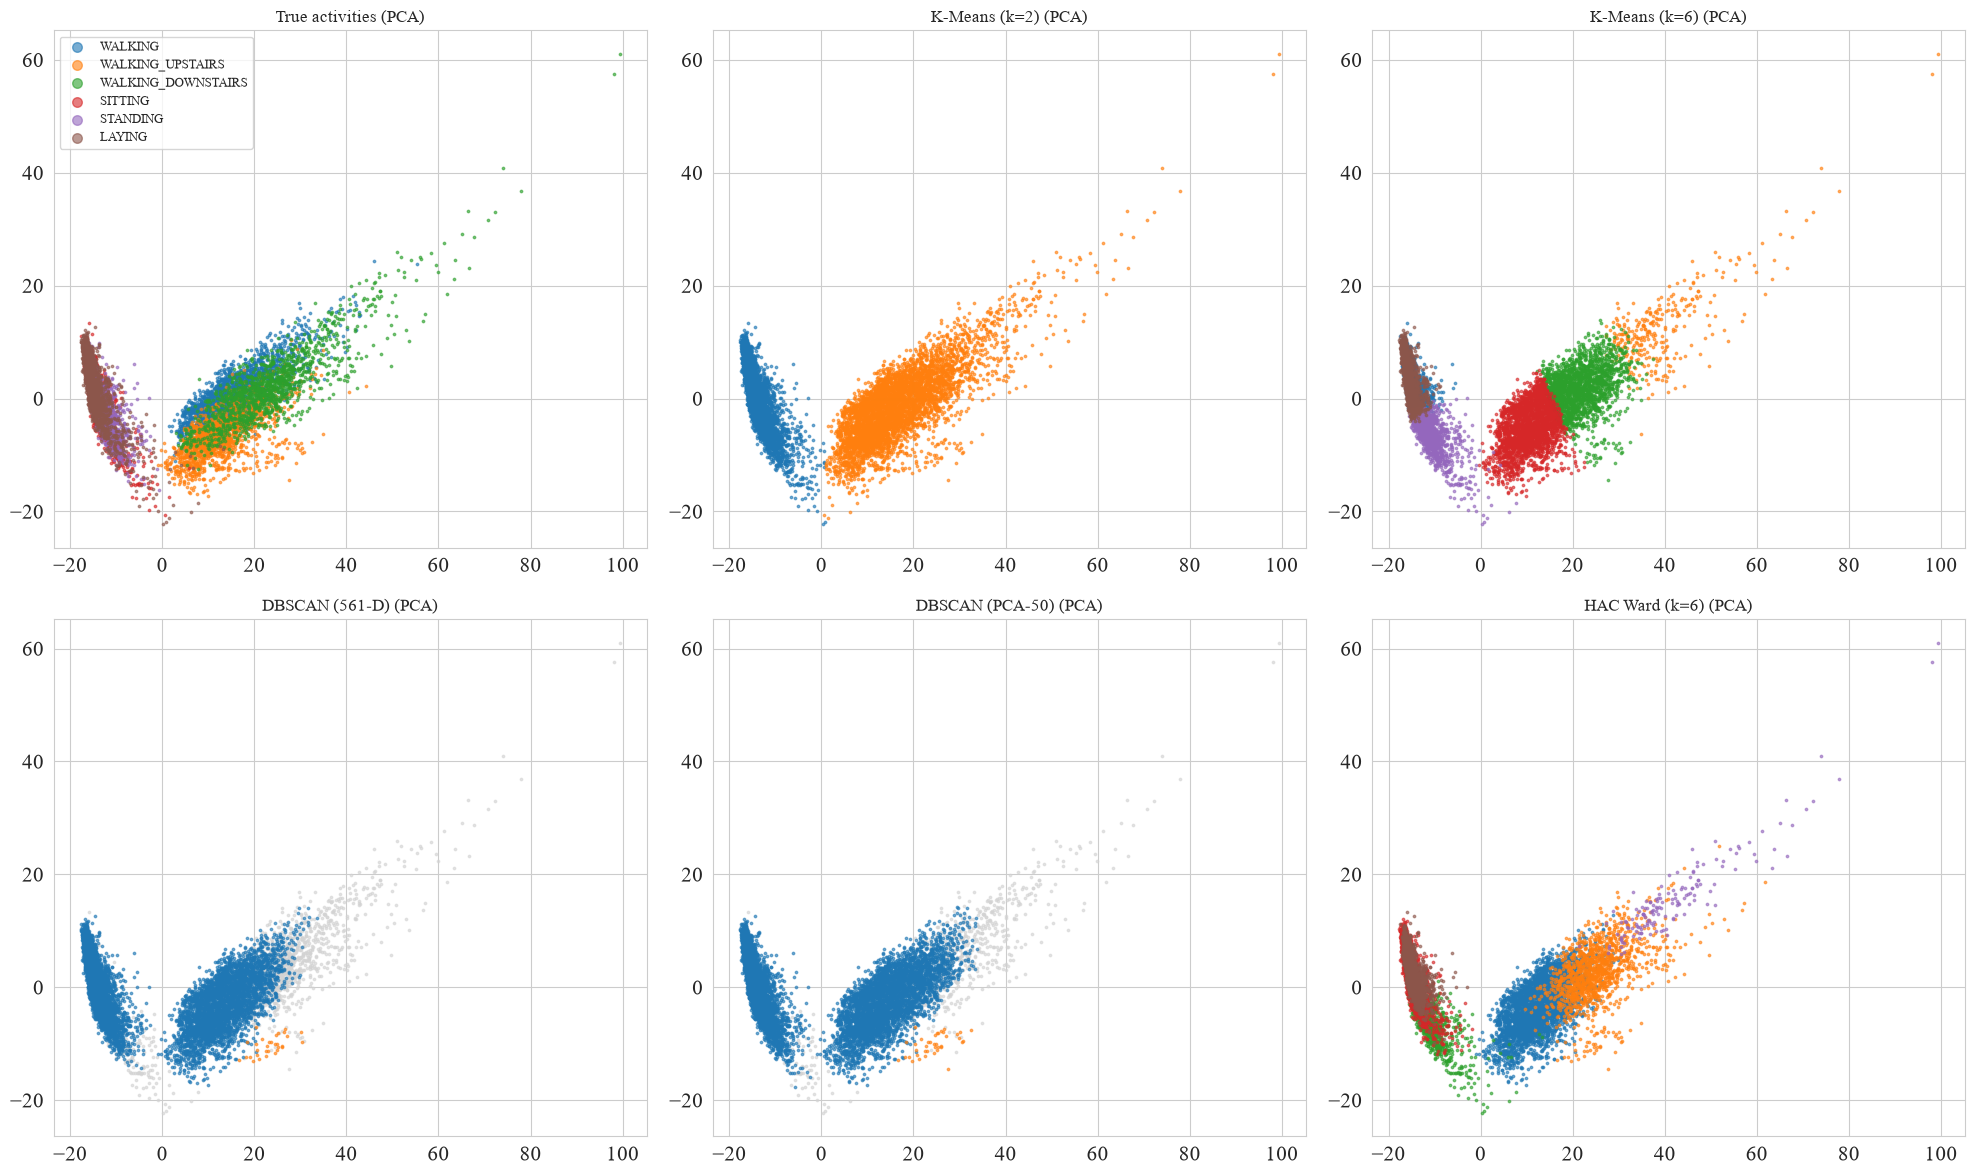

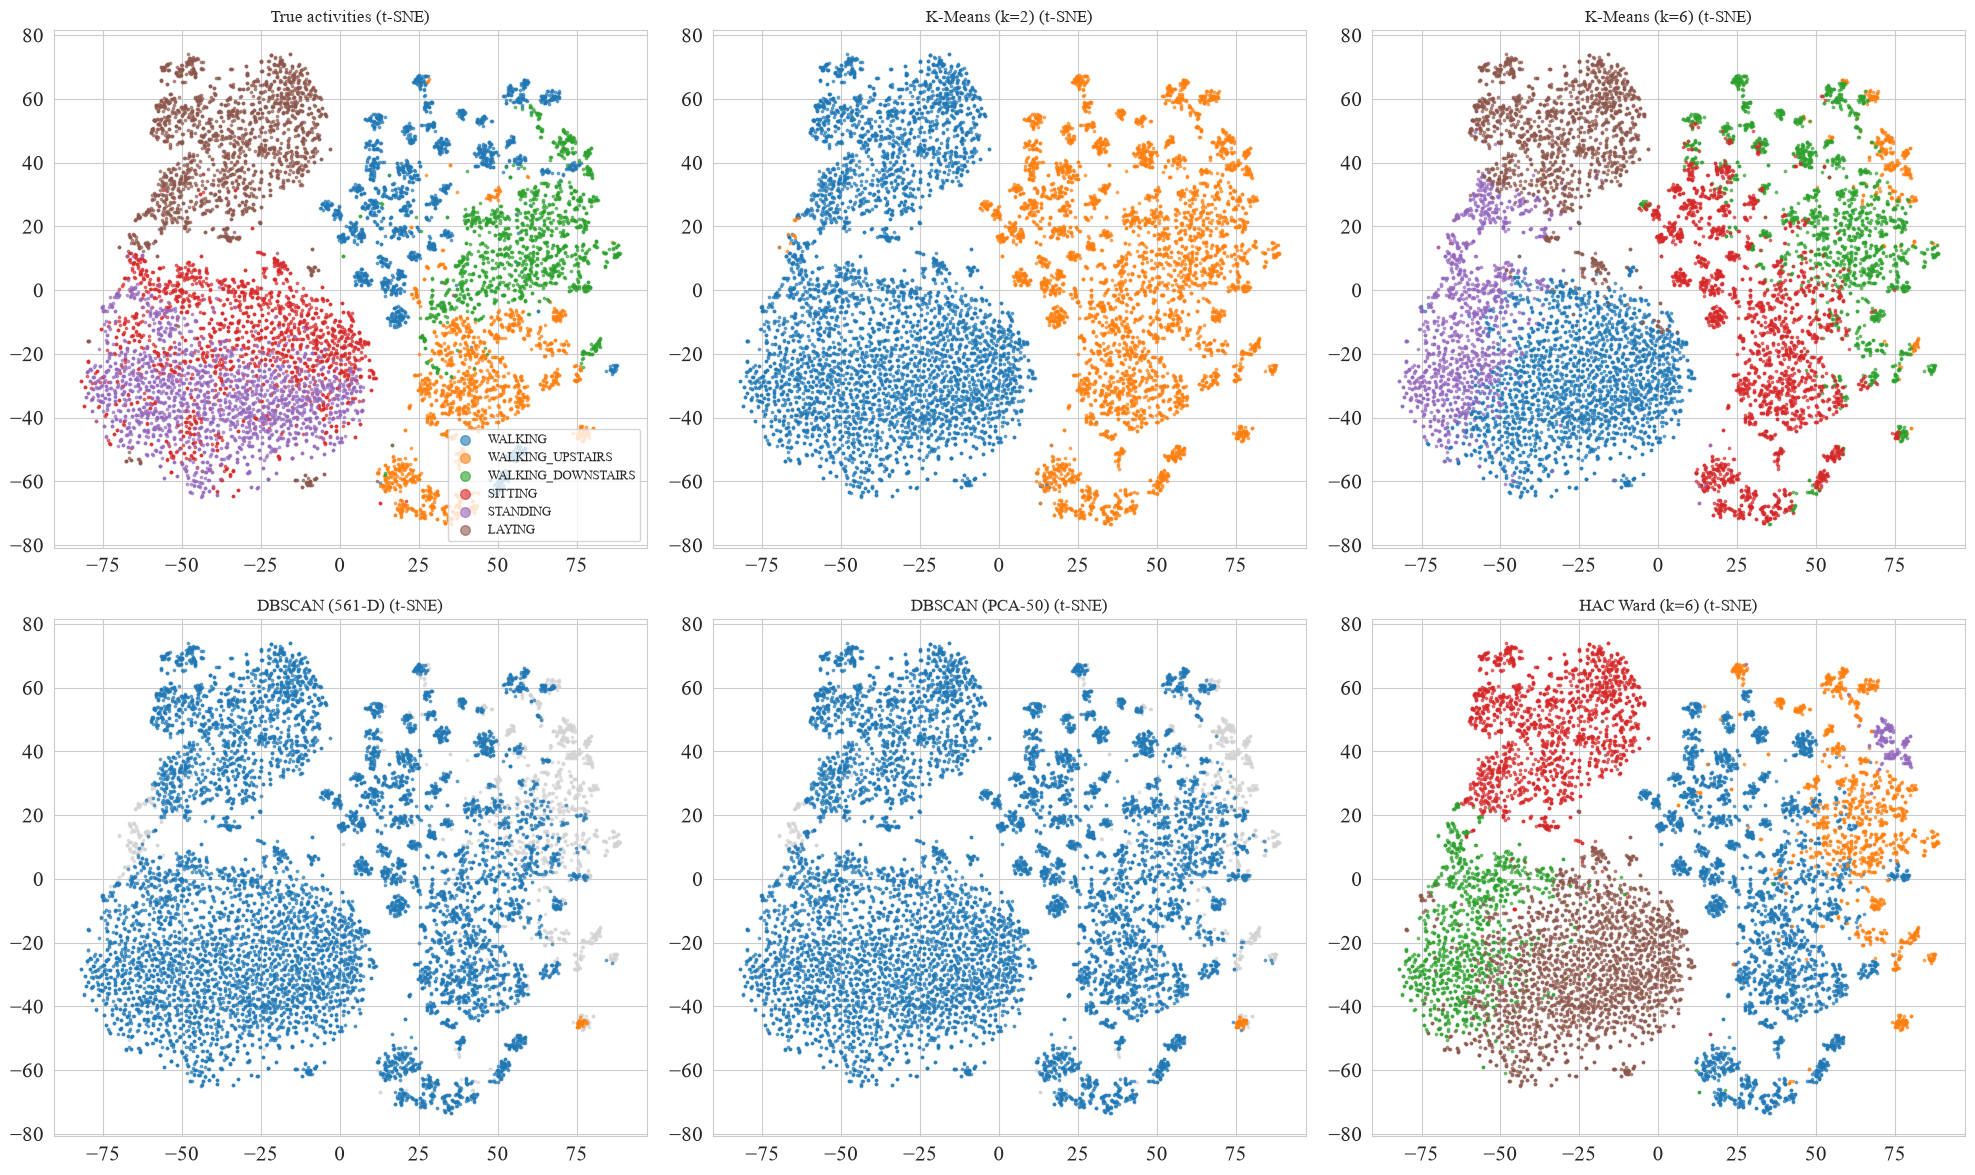

In [15]:
titles = list(final.keys())
panels = [("True activities", y_true)] + [(t, final[t]) for t in titles]

for name, Z, path in [("PCA", Z_pca, "figures/06_cluster_scatter_pca.png"),
                      ("t-SNE", Z_tsne, "figures/07_cluster_scatter_tsne.png")]:
    fig, axes = plt.subplots(2, 3, figsize=(20, 12))
    for ax, (title, labels) in zip(axes.ravel(), panels):
        if title == "True activities":
            for a in order:
                m = (df["activity"] == a).values
                ax.scatter(Z[m, 0], Z[m, 1], s=3, alpha=0.6, color=palette[a], label=a)
            ax.legend(fontsize=9, markerscale=4)
            ax.set_title(f"{title} ({name})", fontsize=12)
        else:
            scatter_panel(ax, Z, np.asarray(labels), f"{title} ({name})")
    for ax in axes.ravel()[len(panels):]:
        ax.axis("off")
    plt.tight_layout()
    plt.savefig(path, dpi=150)
    plt.show()
    plt.close()

## Metric comparison

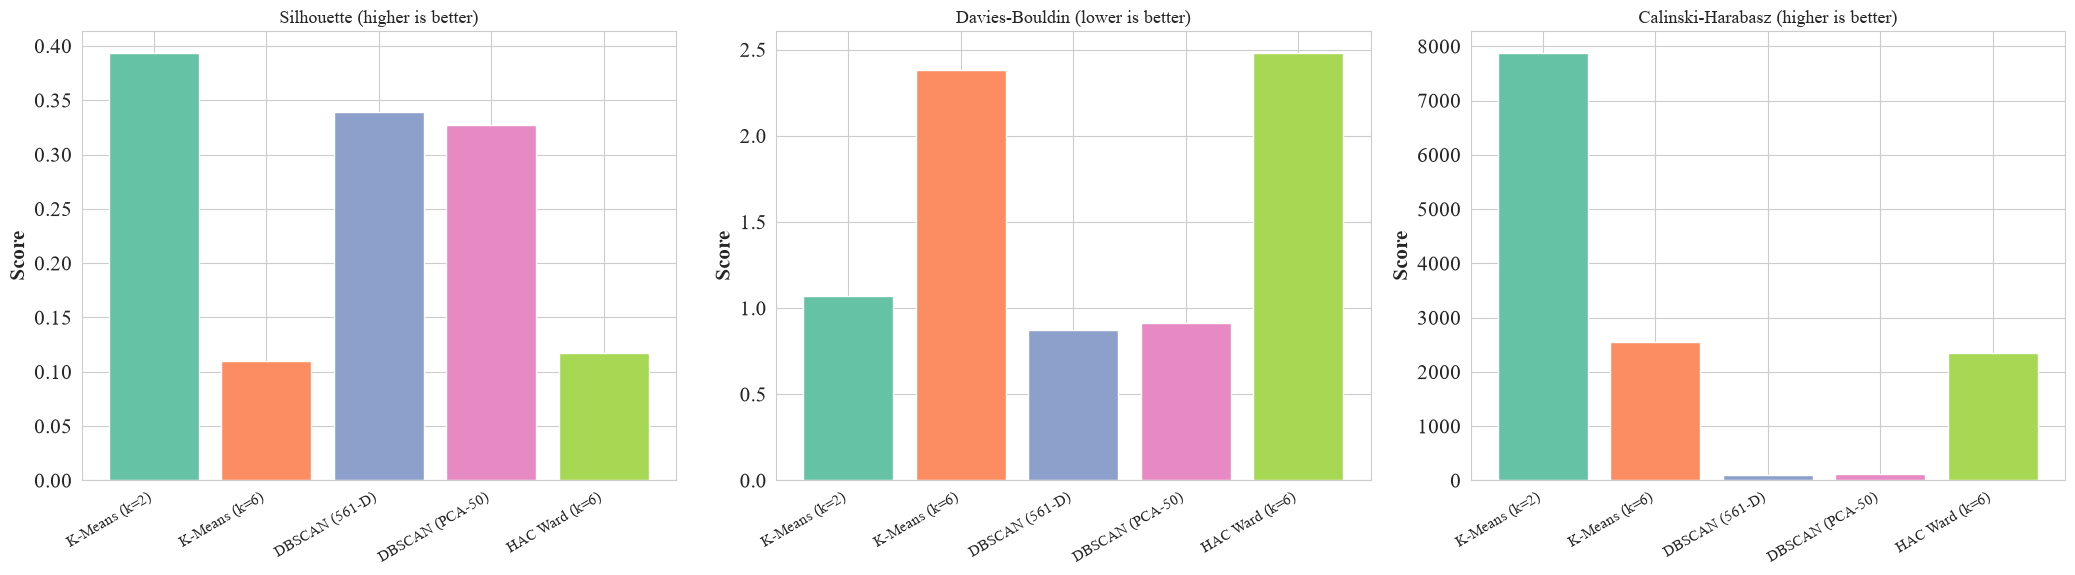

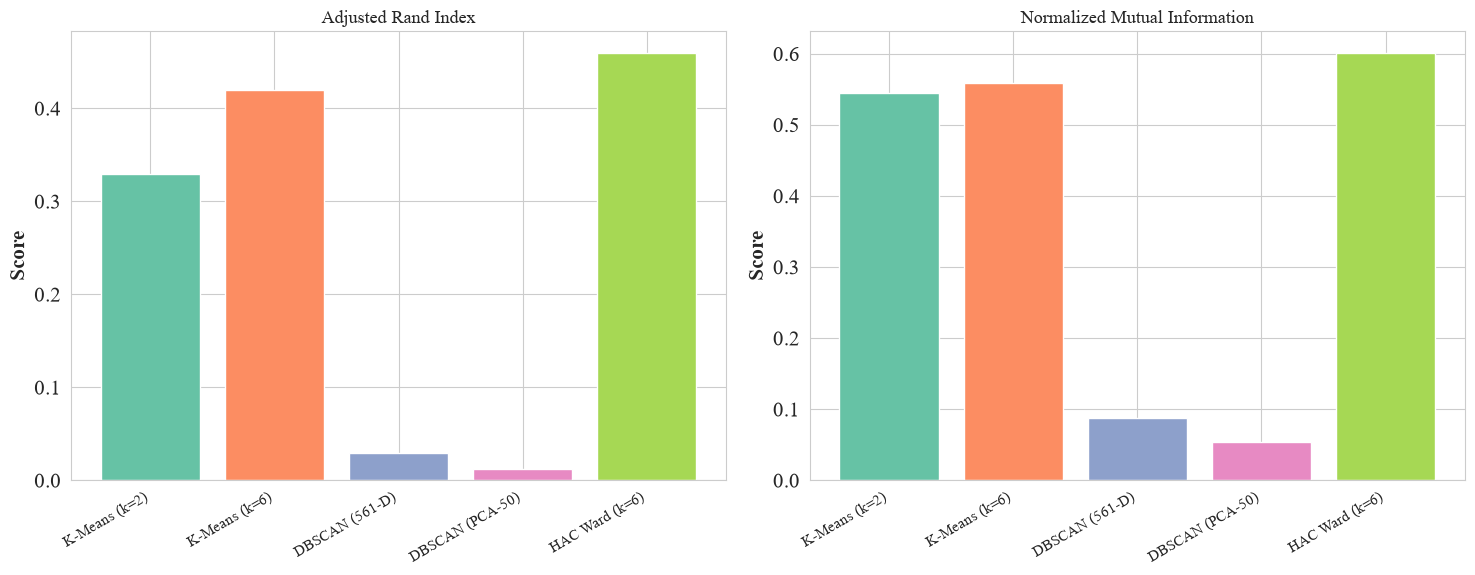

In [16]:
metric_titles = [("silhouette", "Silhouette (higher is better)"),
                 ("davies_bouldin", "Davies-Bouldin (lower is better)"),
                 ("calinski_harabasz", "Calinski-Harabasz (higher is better)")]
fig, axes = plt.subplots(1, 3, figsize=(21, 6))
for ax, (col, title) in zip(axes, metric_titles):
    ax.bar(range(len(compare_df)), compare_df[col], color=sns.color_palette("Set2", len(compare_df)))
    ax.set_xticks(range(len(compare_df)))
    ax.set_xticklabels(compare_df["model"], rotation=30, ha="right", fontsize=11)
    ax.set_title(title, fontsize=13)
    ax.set_ylabel("Score")
plt.tight_layout()
plt.savefig("figures/08_internal_metrics.png", dpi=150)
plt.show()
plt.close()

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, (col, title) in zip(axes, [("ari", "Adjusted Rand Index"), ("nmi", "Normalized Mutual Information")]):
    ax.bar(range(len(compare_df)), compare_df[col], color=sns.color_palette("Set2", len(compare_df)))
    ax.set_xticks(range(len(compare_df)))
    ax.set_xticklabels(compare_df["model"], rotation=30, ha="right", fontsize=11)
    ax.set_title(title, fontsize=13)
    ax.set_ylabel("Score")
plt.tight_layout()
plt.savefig("figures/09_external_metrics.png", dpi=150)
plt.show()
plt.close()

## Clusters vs activities

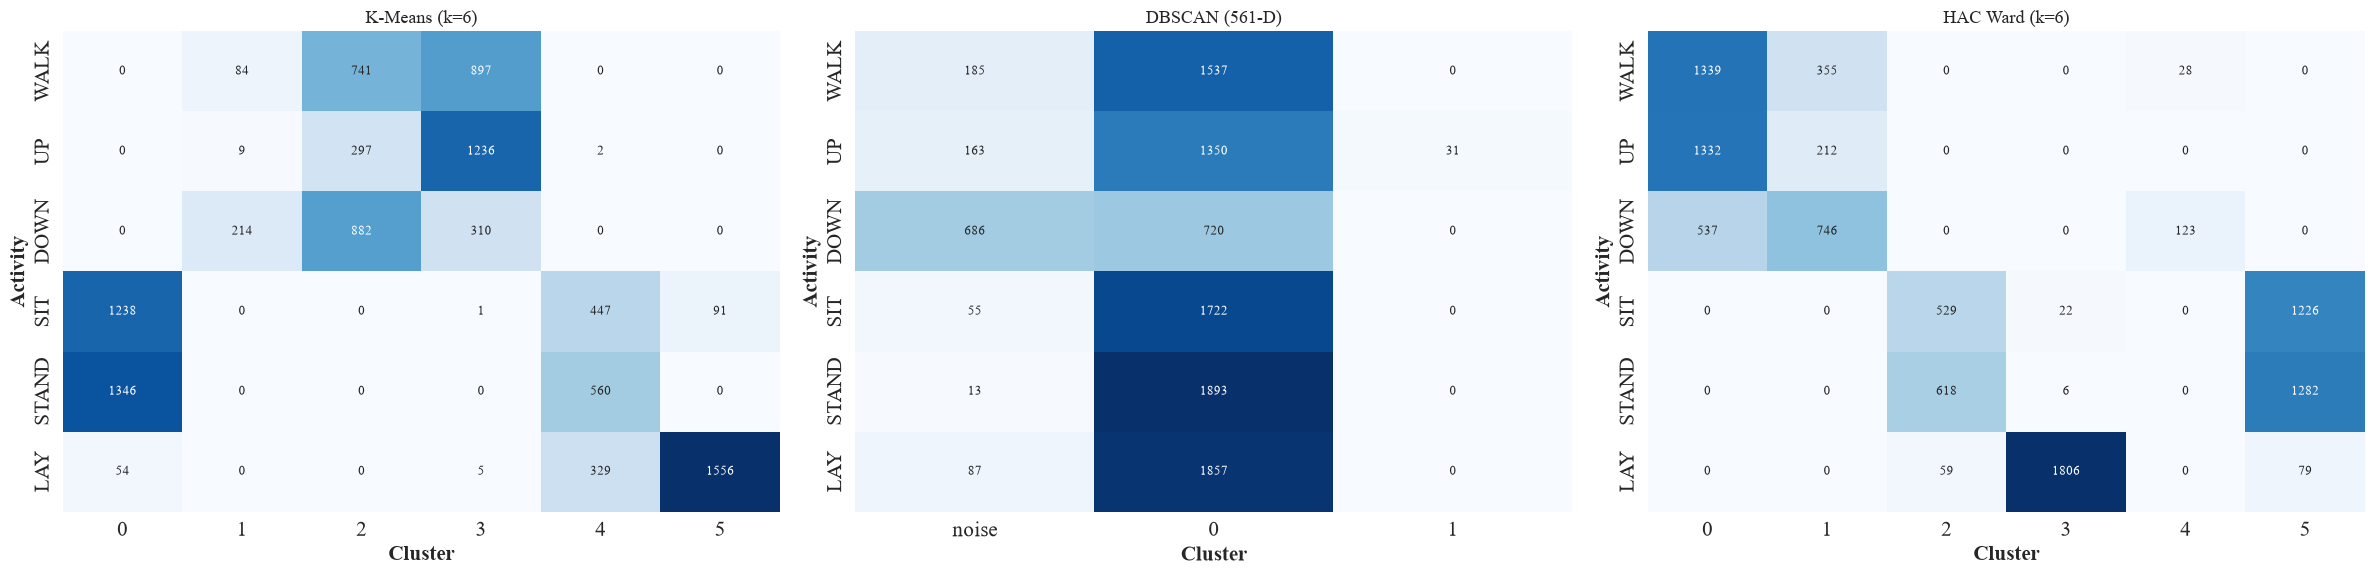

In [17]:
heat = {"K-Means (k=6)": km_models[6].labels_,
        "DBSCAN (561-D)": best_full_labels,
        "HAC Ward (k=6)": hac.labels_}
fig, axes = plt.subplots(1, 3, figsize=(24, 6))
for ax, (name, labels) in zip(axes, heat.items()):
    ct = pd.crosstab(df["activity"].map(short), labels).reindex([short[a] for a in order])
    ct.columns = ["noise" if c == -1 else str(c) for c in ct.columns]
    sns.heatmap(ct, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax, annot_kws={"size": 9})
    ax.set_title(name, fontsize=13)
    ax.set_xlabel("Cluster"); ax.set_ylabel("Activity")
plt.tight_layout()
plt.savefig("figures/10_cluster_activity_heatmaps.png", dpi=150)
plt.show()
plt.close()

## Save results

In [18]:
with open("results_summary.txt", "w") as f:
    f.write(f"Dataset shape: {df.shape}\n")
    f.write(f"Volunteers: {len(np.unique(subjects))}\n")
    f.write(f"Activity counts: {df['activity'].value_counts().to_dict()}\n")
    f.write(f"2-D PCA explained variance: {pca2.explained_variance_ratio_.sum():.4f}\n")
    f.write(f"50-component PCA explained variance: {pca50.explained_variance_ratio_.sum():.4f}\n\n")
    f.write(f"k by elbow: {k_elbow} | k by silhouette: {k_sil} | best_k used: {best_k}\n\n")
    f.write("K-Means elbow table:\n" + km_df.round(4).to_string(index=False) + "\n\n")
    f.write(f"DBSCAN full-space eps grid: {eps_full.tolist()}\n")
    f.write(db_full.round(4).to_string(index=False) + "\n")
    f.write(f"Selected: {dict(best_db_full.round(4))}\n\n")
    f.write(f"DBSCAN PCA-50 eps grid: {eps_pca.tolist()}\n")
    f.write(db_pca.round(4).to_string(index=False) + "\n")
    f.write(f"Selected: {dict(best_db_pca.round(4))}\n\n")
    f.write("Linkage comparison (cut at 6 clusters):\n" + link_df.round(4).to_string(index=False) + "\n\n")
    f.write("Algorithm comparison:\n" + compare_df.round(4).to_string(index=False) + "\n")
print("Done.")

Done.
